In [ ]:
                #------ Handling Numerical Missing Value-----#

# There are two way to handle numerical missing value
    # 1. Univariate Imputation: 
    # When one value is missing in a column and fill this value using other value (mean, any random value) of this column called univariate imputation.

 # 1. Multivariate Imputation: 
    # When one value is missing in a column and fill this value using other value (mean, any random value) of more than one column called multivariate imputation.

In [ ]:
        #-----Univariate Analysis-----#
# Technique for Univariate Imputation
    # Mean/meadian
    # Arbitary
    # End of Distribition
    # Random Value

# Mean: If column is normally distributed use mean
# Median: If data is not normally distributed (skewed) use median
    # It is simple technique
    # If missing value is more than 5%, it is not reliable
    # Distribution will be change
    # Outlier creates
    # Correlation and Covariance will change
# When to use:
    # MCAR(Missing Completely at random)
    # Less than 5%


In [1]:
# Coding Example:

# Add required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


In [29]:
# Import Dataset
Data=pd.read_csv('titanic_toy.csv')

In [30]:
# Basic info
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [4]:
# Check percentage of missing value
Data.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [31]:
# Now perform train test split
X=Data.drop(columns='Survived')
y=Data['Survived']
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.2, random_state=2)

In [6]:
# Shape of train dataset
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [7]:
# Check null value
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [32]:
# Calculate mean/meadian of age and fare column
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].median()

In [33]:
# Now fill the column
X_train['Age_mean']=X_train['Age'].fillna(mean_age)
X_train['Age_median']=X_train['Age'].fillna(median_age)

X_train['Fare_mean']=X_train['Fare'].fillna(mean_fare)
X_train['Fare_median']=X_train['Fare'].fillna(median_fare)

In [10]:
# Random Sample 
X_train.sample(3)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
246,25.0,7.7750,0,25.000000,25.00,7.7750,7.7750
410,NaN,7.8958,0,29.785904,28.75,7.8958,7.8958
282,16.0,9.5000,0,16.000000,16.00,9.5000,9.5000


In [34]:
# Calculate variance of age and fare column
print('Variance of Original Age variable:', X_train['Age'].var())
print('Variance of Age variable after mean imputation:', X_train['Age_mean'].var())
print('Variance of Age variable after median imputation:', X_train['Age_median'].var())
print('Variance of Original fare variable:', X_train['Fare'].var())
print('Variance of Fare variable after mean imputation:', X_train['Fare_mean'].var())
print('Variance of Fare variable after median imputation:', X_train['Fare_median'].var())



Variance of Original Age variable: 204.34951339046142
Variance of Age variable after mean imputation: 161.81262452718676
Variance of Age variable after median imputation: 161.98956633460548
Variance of Original fare variable: 2448.1979137063163
Variance of Fare variable after mean imputation: 2324.2385256705534
Variance of Fare variable after median imputation: 2340.09102197536


Text(0.5, 1.0, 'Distribution comparision of Original, Mean and Median Age Variable')

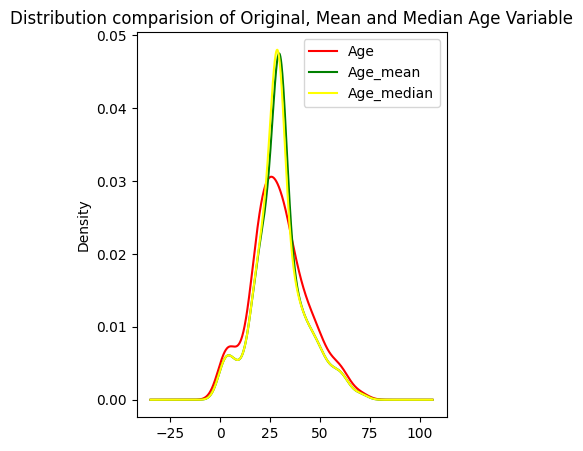

In [35]:
# Show the distribution
plt.figure(figsize=(4,5))
# Distribution of orgiginal age
X_train['Age'].plot(kind='kde', color='red', legend='True')
# Distribution of mean_age
X_train['Age_mean'].plot(kind='kde', color='green', legend='True')
# Distribution of median_age
X_train['Age_median'].plot(kind='kde', color='yellow', legend='True')

plt.title("Distribution comparision of Original, Mean and Median Age Variable")

In [ ]:
# Distribution of Original and mean, meadian age is not same.

Text(0.5, 1.0, 'Distribution comparision of Original, Mean and Median Age Variable')

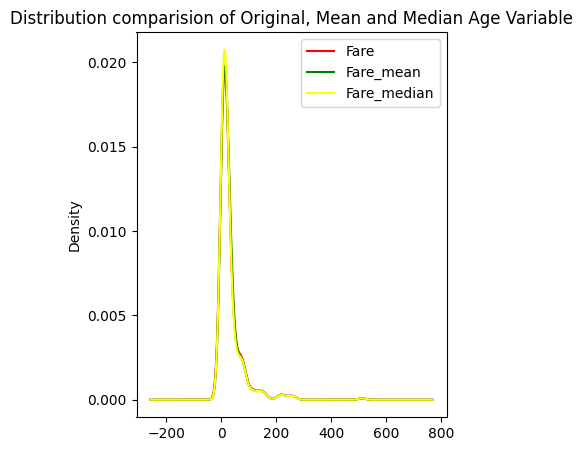

In [36]:
# Show the distribution
plt.figure(figsize=(4,5))
# Distribution of orgiginal age
X_train['Fare'].plot(kind='kde', color='red', legend='True')
# Distribution of mean_age
X_train['Fare_mean'].plot(kind='kde', color='green', legend='True')
# Distribution of median_age
X_train['Fare_median'].plot(kind='kde', color='yellow', legend='True')

plt.title("Distribution comparision of Original, Mean and Median Age Variable")

In [ ]:
# Distribution of Original and mean, median are same

In [14]:
# Calculate covariance
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,64.858859
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.476305
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,51.358000
Age_median,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,53.553455
Fare_mean,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
Fare_median,64.858859,2448.197914,16.476305,51.358000,53.553455,2324.238526,2340.091022


In [15]:
# Calculate Correlation
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090156,0.087356
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205499,0.205942
Age_mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.086078,0.083461
Age_median,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089673,0.086982
Fare_mean,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,0.996607
Fare_median,0.087356,1.000000,0.205942,0.083461,0.086982,0.996607,1.000000


<Axes: >

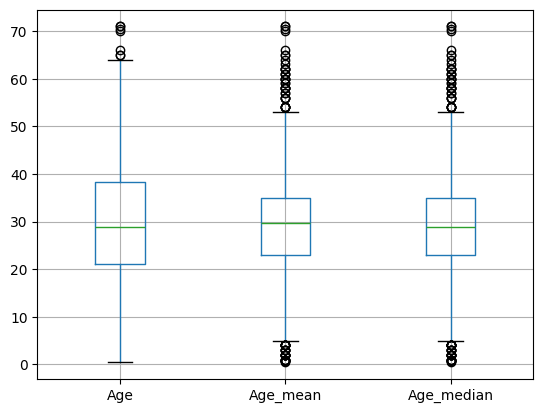

In [37]:
# Check outlier
plt.Figure(figsize=(5,5))
X_train[['Age', 'Age_mean', 'Age_median']].boxplot()

In [ ]:
# After imputation outlier increased

<Axes: >

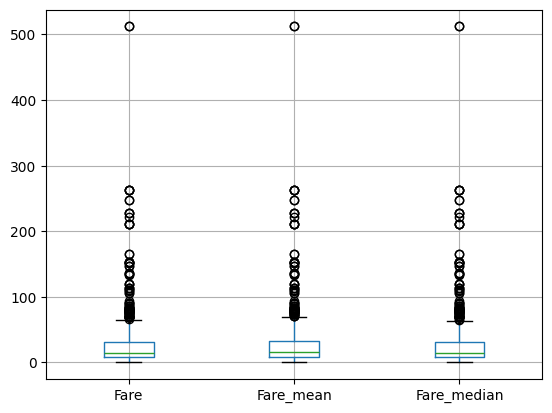

In [38]:
X_train[['Fare', 'Fare_mean', 'Fare_median']].boxplot()

In [ ]:
# No difference

In [39]:
# Handling Numerical Value using Sklearn
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=2)

In [40]:
# Create simple imputer object
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [41]:
trf=ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
],remainder='passthrough')

In [42]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [43]:
ColumnTransformer(
    remainder='passthrough',
    transformers=[('imputer1', SimpleImputer(strategy='median'), ['Age']),
                  ('imputer2', SimpleImputer(strategy='mean'), 'Fare')]
    )

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [44]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [45]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [46]:
X_train=trf.transform(X_train)

In [47]:
X_test=trf.transform(X_test)